<a href="https://colab.research.google.com/github/FuscaLuocaG/LUNG-CANCER-ANALYSIS/blob/main/Phase_2_EDA_Censoring_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lifelines

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines import KaplanMeierFitter
from IPython.terminal.embed import line_magic
from google.colab import drive
drive.mount('/content/drive')

from lifelines.datasets import load_lung

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.DataFrame(load_lung())

pd.set_option('display.max_rows', 100)

In [4]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/df_raw_NCCTG_lungC.csv')

# EDA & Censoring Audit

In [5]:
df.head(15)

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0
5,12.0,1022,0,74,1,1.0,50.0,80.0,513.0,0.0
6,7.0,310,1,68,2,2.0,70.0,60.0,384.0,10.0
7,11.0,361,1,71,2,2.0,60.0,80.0,538.0,1.0
8,1.0,218,1,53,1,1.0,70.0,80.0,825.0,16.0
9,7.0,166,1,61,1,2.0,70.0,70.0,271.0,34.0


All feature columns in this NCCTG dataset are single baseline measurements taken at the beginning of the study (upon patient enrollment) before clinical trial treatment started.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   inst       227 non-null    float64
 1   time       228 non-null    int64  
 2   status     228 non-null    int64  
 3   age        228 non-null    int64  
 4   sex        228 non-null    int64  
 5   ph.ecog    227 non-null    float64
 6   ph.karno   227 non-null    float64
 7   pat.karno  225 non-null    float64
 8   meal.cal   181 non-null    float64
 9   wt.loss    214 non-null    float64
dtypes: float64(6), int64(4)
memory usage: 17.9 KB


In [7]:
duplicated = df.duplicated().any()

if duplicated:
  print('There are duplicated rows')
else:
  print("No duplicated rows")

No duplicated rows


In [8]:
df.isnull().sum()

,0
inst,1
time,0
status,0
age,0
sex,0
ph.ecog,1
ph.karno,1
pat.karno,3
meal.cal,47
wt.loss,14


In [9]:
df_eda = df.copy()

## Univariate Distribution Analysis.

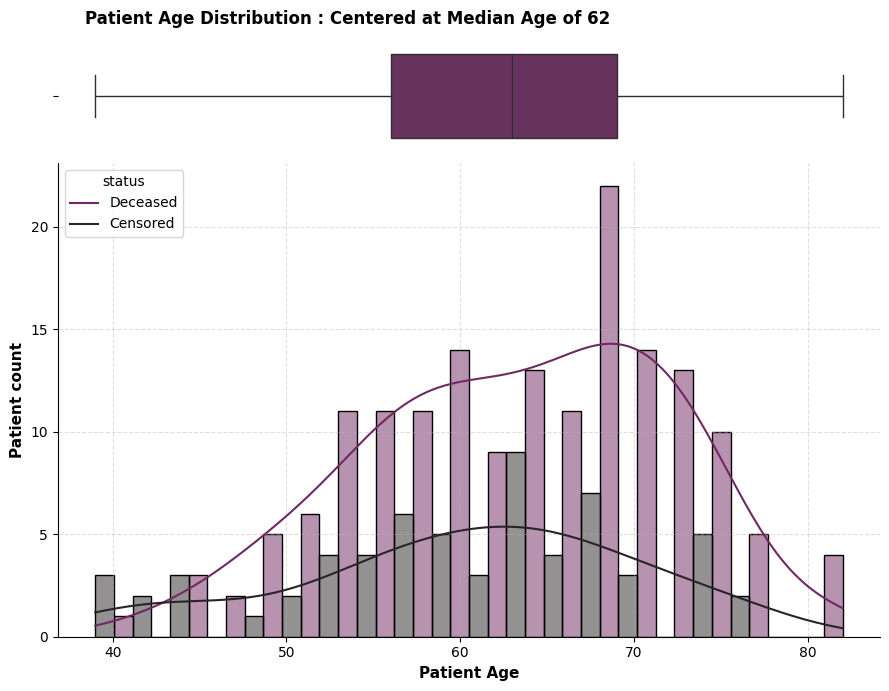

In [10]:

fig, (as_box, ax_hist) = plt.subplots(nrows = 2, ncols = 1, figsize = (9, 7), sharex = True, gridspec_kw = {'height_ratios' : [0.18, 0.82]})

sns.boxplot(data = df_eda, x = 'age', ax = as_box, color = '#702963', fliersize = 4)
as_box.set(xlabel = "")
as_box.tick_params(bottom = False)
sns.despine(ax = as_box, left = True, bottom = True)

sns.histplot(data = df_eda, x = 'age', hue = 'status', kde = True, bins = 20, palette = 'dark:#702963', ax = ax_hist, multiple = 'dodge')
ax_hist.set_xlabel('Patient Age', fontweight = 'bold', fontsize = 11)
ax_hist.set_ylabel('Patient count', fontweight = 'bold', fontsize = 11)
ax_hist.grid(True, linestyle = '--', alpha = 0.4)
sns.despine(ax = ax_hist)
ax_hist.legend(title = 'status', labels = ['Deceased', 'Censored'], loc = 'upper left' )

plt.suptitle('Patient Age Distribution : Centered at Median Age of 62', fontsize = 12, fontweight = 'bold', x = 0.10, ha= 'left', y = 0.98)
plt.tight_layout()
plt.show()

Age Demographic Findings & Modeling Impact

- **Distribution Profile:** Patient age follows an approximately normal distribution centered around a median of 62 years (IQR: 56–69 years), spanning from 39 to 82 years.

- **Mortality Rate by Age:** Mortality events occur consistently across all age brackets above 50, indicating age should be evaluated alongside ECOG performance status rather than as a standalone isolated hazard driver.

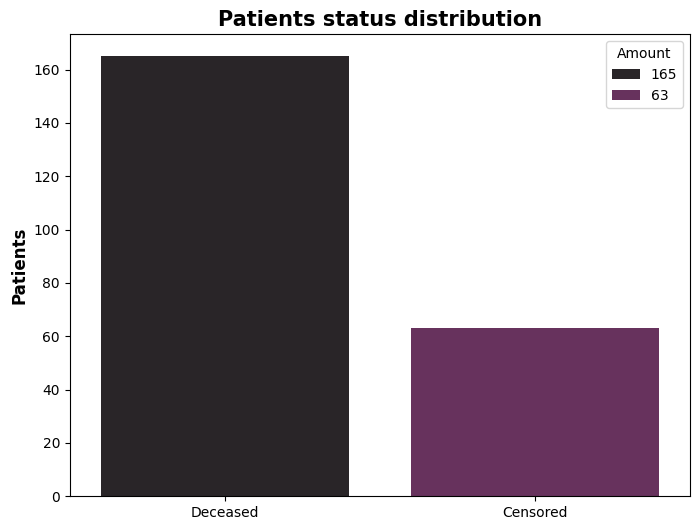

In [11]:
df_eda['Patient_state'] = df['status'].map({1 : 'Deceased', 0 : 'Censored'})

plt.figure(figsize = (8, 6));

ax = sns.countplot(data = df_eda, x = 'Patient_state', hue = 'Patient_state', palette = 'dark:#702963', legend = False);
plt.title("Patients status distribution", fontweight = 'bold', fontsize = 15)
plt.xlabel("")
plt.ylabel("Patients", fontweight = 'bold', fontsize = 12)
plt.legend(title = 'Amount', labels = ['165', '63'])

plt.show()

- We can see that 72.4% of the patients were Deceased and 27.6% Censored.

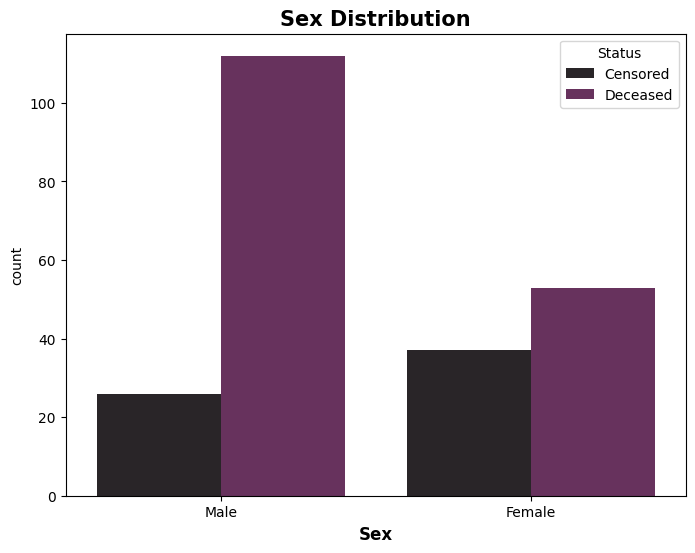

In [12]:
df_eda['SexMapped'] = df['sex'].map({1 : 'Male', 2 : 'Female'})

plt.figure(figsize = (8, 6))

sns.countplot(x = df_eda['SexMapped'], hue = df['status'], palette = 'dark:#702963', legend = True)
plt.title('Sex Distribution', fontweight = 'bold', fontsize = 15)
plt.xlabel('Sex', fontweight = 'bold', fontsize = 12)
plt.legend(title = 'Status', labels = ['Censored', 'Deceased'])

plt.show()

Sex Distribution & Mortality Impact

- Clinical Finding: Male patients exhibit a significantly higher mortality rate (81% deceased vs. 19% censored), whereas female patients show a much higher censorship rate (41% censored vs. 59% deceased). This indicates longer median survival times for females in this cohort.

- Modeling Implication: sex is a strong candidate as a stratified variable or primary hazard predictor in both Cox Proportional Hazards and Random Survival Forests.

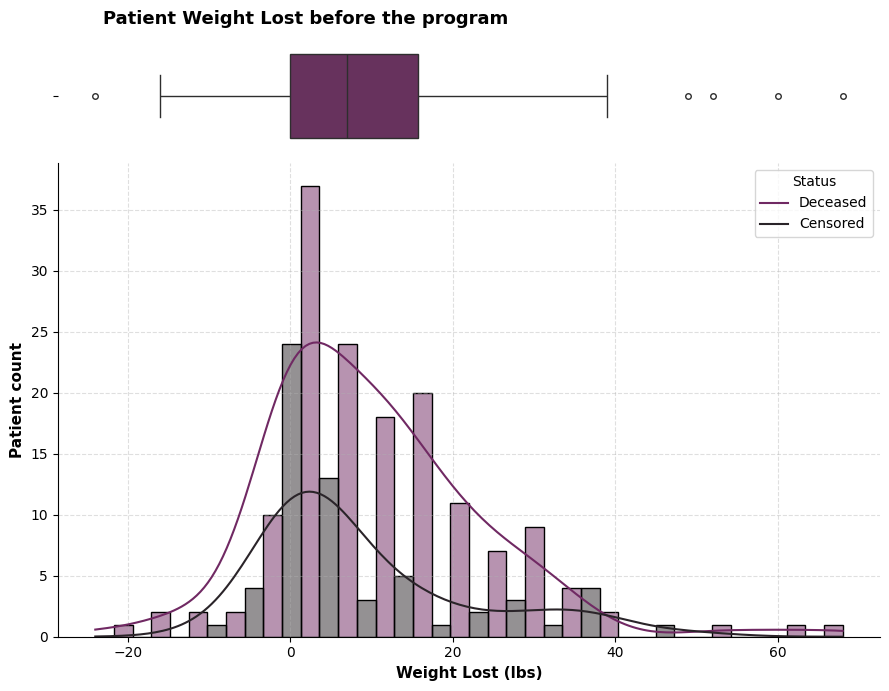

In [13]:
fig, (ax_box, ax_hist) = plt.subplots(ncols = 1, nrows = 2, figsize = (9,7), sharex = True, gridspec_kw= {'height_ratios' : [0.18, 0.82]})

sns.boxplot(data = df_eda, x = 'wt.loss', ax = ax_box, color = '#702963', fliersize = 4)
ax_box.set(xlabel = '')
ax_box.tick_params(bottom = False)
sns.despine(ax = ax_box, left = True, bottom = True)

sns.histplot(data = df_eda, x = 'wt.loss', hue = 'status', kde = True, bins = 20, palette = 'dark:#702963', ax = ax_hist, multiple = 'dodge')
ax_hist.set_xlabel("Weight Lost (lbs)", fontweight = 'bold', fontsize = 11)
ax_hist.set_ylabel('Patient count', fontweight = 'bold', fontsize = 11)
ax_hist.grid(True, linestyle = '--', alpha = 0.4)
plt.legend(title = 'Status', labels = ['Deceased', 'Censored'])
sns.despine(ax = ax_hist)

fig.suptitle('Patient Weight Lost before the program', fontweight = 'bold', fontsize = 13, x = 0.12, ha = 'left', y = 0.98)
plt.tight_layout()

plt.show()

Weight Change Distribution & Clinical TakeawaysPrimary Clustering:

- Weight loss prior to program entry is right-skewed, with the majority of patients losing between 0 and 16 lbs (median $\approx 7$ lbs).

- Extreme Weight Loss Hazard (Cachexia): Patients in the far-right tail with extreme weight loss ($> 30$ lbs) exhibit near 100% mortality. This aligns with clinical expectations around cancer cachexia (progressive muscle/fat wasting)

- Weight Gain Subset ($< 0$ lbs): A very small minority of patients ($n < 10$) gained weight prior to entry. Due to the small sample size in this left tail, weight gain cannot be interpreted as a statistically significant protective factor without further stratified modeling.

Modeling Implication: wt.loss contains significant right-skewed outliers ($> 40$ lbs). Non-parametric algorithms like Random Survival Forests will handle these extreme values natively, whereas linear models like Cox PH may benefit from log-transformation or binning.

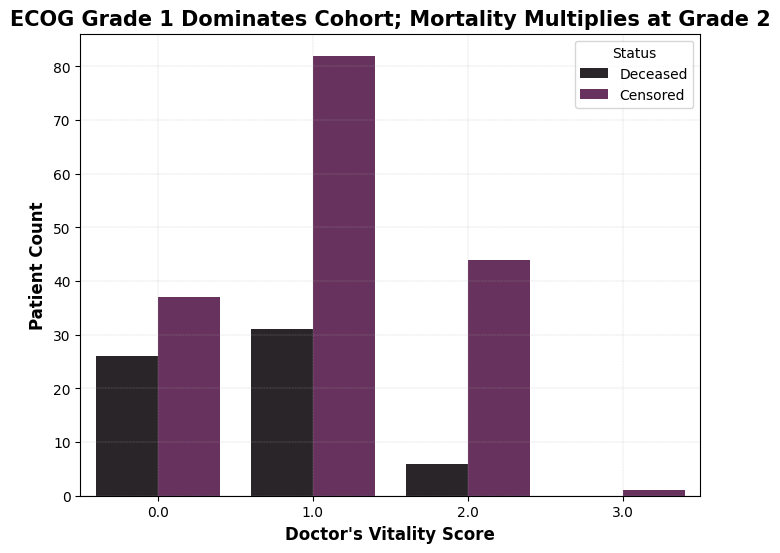

In [14]:
plt.figure(figsize = (8, 6))

sns.countplot(data = df_eda, x = 'ph.ecog', hue = 'status', palette = "dark:#702963")
plt.xlabel("Doctor's Vitality Score", fontweight = 'bold', fontsize = 12)
plt.ylabel("Patient Count", fontweight = 'bold', fontsize = 12)
plt.legend(title = 'Status', labels = ['Deceased', 'Censored'])
plt.grid(True, linestyle = '--', linewidth = 0.2)
plt.title('ECOG Grade 1 Dominates Cohort; Mortality Multiplies at Grade 2', fontweight = 'bold', fontsize = 15)

plt.show()

Physician ECOG Performance Status Findings

- Cohort Functional Distribution: The vast majority of enrolled patients fall into ECOG 1 ($n = 82$, restricted in strenuous activity) and ECOG 0 ($n = 37$, fully active), followed by ECOG 2 ($n = 44$, bedridden $<50\%$ of waking hours). Severe impairment (ECOG 3) is rare ($n = 1$), representing an extreme outlier, and it will be replaced by ECOG 2 finishing EDA.

- Risk Escalation: The ratio of mortality events rises sharply as performance status deteriorates from ECOG 0 to ECOG 2.

- Modeling Implication: Because ECOG status is ordinal and exhibits strong mortality separation, it serves as a critical baseline covariate for Cox Proportional Hazards modeling and stratifying Kaplan-Meier curves.

-----------------------------------------------------------------------------------

Univariate Analysis Key Insights

- **Target Event Distribution**: Deceased events ($n=165$, $72.4\%$) outnumber right-censored cases ($n=63$, $27.6\%$) by more than 2.5:1, establishing a strong event rate for hazard estimation.

- **Age Demographics**: Patient age follows a normal distribution centered around a median of 62 years, with the vast majority falling between 50 and 75 years old.

- **Outlier & Data Quality Audit**: No corrupt data-entry errors were found. Extremes observed in weight loss prior to study onset (wt.loss) and age represent authentic clinical severity rather than statistical noise.

- **Data Integrity & Missingness**: Identified 47 missing values in meal.cal, 1 missing values in, ph.karno and ph.ecog, 3 missing values in pat.karno and 14 in wt.loss, making median imputation necessary during preprocessing to preserve the sample size ($N=228$). Zero duplicate rows were detected.


Next Step: Fill the empty cells in each column with the median metric just for the bivariate EDA Analysis. A more robust method will be used for the modeling phase, so preventing Data Leakage.



## Simple Imputation with Median().



In [15]:
df_eda.columns

Index(['inst', 'time', 'status', 'age', 'sex', 'ph.ecog', 'ph.karno',
       'pat.karno', 'meal.cal', 'wt.loss', 'Patient_state', 'SexMapped'],
      dtype='object')

In [16]:
df_eda.isnull().sum()

,0
inst,1
time,0
status,0
age,0
sex,0
ph.ecog,1
ph.karno,1
pat.karno,3
meal.cal,47
wt.loss,14


In [17]:
missing_cols = ['ph.ecog', 'ph.karno', 'pat.karno', 'meal.cal', 'wt.loss']

for col in missing_cols:
  df_eda[col] = df_eda[col].fillna(df_eda[col].median())

print("Remaining missing values in df_eda: ")
print(df_eda[missing_cols].isnull().sum())

Remaining missing values in df_eda: 
ph.ecog      0
ph.karno     0
pat.karno    0
meal.cal     0
wt.loss      0
dtype: int64


## Multi and Bivariate - Analysis



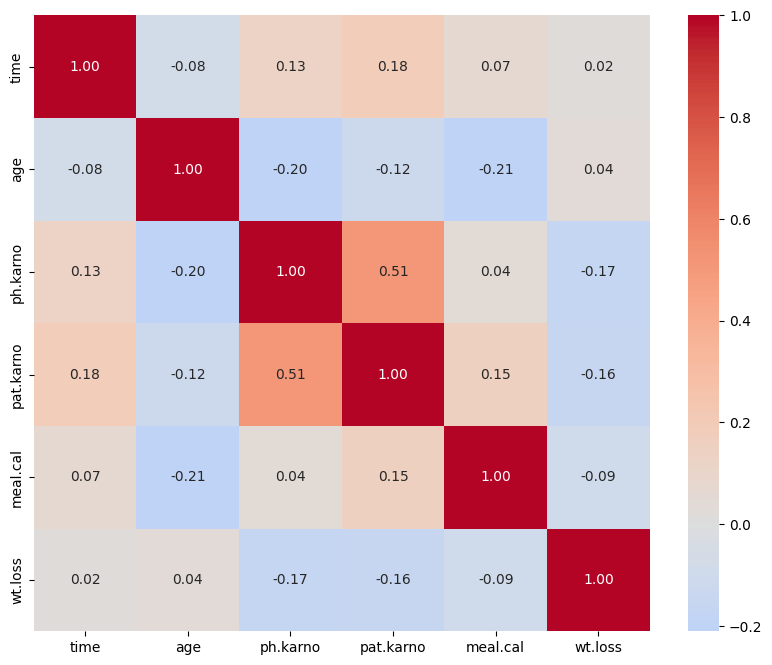

In [18]:
df_eda_matrix = df_eda.drop(columns=['inst', 'status', 'sex', 'ph.ecog']).copy()
#df_eda_matrix['Patient_state'] = df['status'].map({0 : 'Deceased', 1 : 'Censored'})

matrix = df_eda_matrix.select_dtypes(include = 'number')

correlation_matrix = matrix.corr(method = 'pearson', numeric_only= True)
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, square = True, annot = True, cmap = 'coolwarm', fmt = '.2f', cbar = True, center = False)
plt.show()

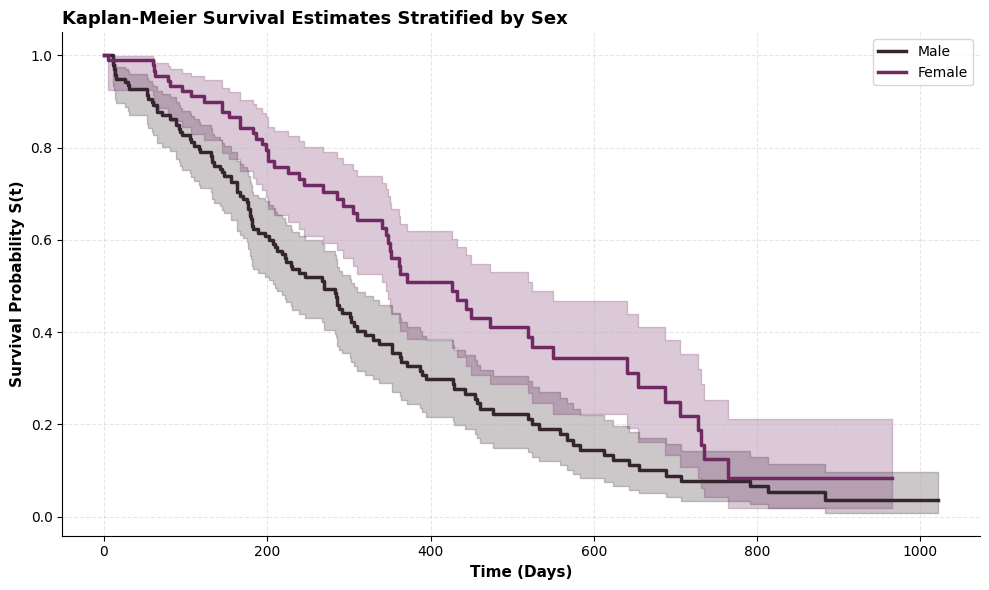

In [19]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize = (10, 6))

males = (df_eda['sex'] == 1)
kmf.fit(durations = df_eda.loc[males, 'time'], event_observed = df_eda.loc[males, 'status'], label = 'Male')

kmf.plot_survival_function(ax = ax, ci_show = True, color = '#34252F', linewidth = 2.5)

female = (df_eda['sex'] == 2)

kmf.fit(durations = df_eda.loc[female, 'time'], event_observed = df_eda.loc[female, 'status'], label = 'Female')
kmf.plot_survival_function(ax = ax, ci_show = True, color = '#702963', linewidth = 2.5)

plt.title('Kaplan-Meier Survival Estimates Stratified by Sex', fontsize = 13, fontweight = 'bold', loc = 'left')
plt.xlabel('Time (Days)', fontsize = 11, fontweight = 'bold')
plt.ylabel('Survival Probability S(t)', fontsize = 11, fontweight = 'bold')
plt.grid(True, linestyle = '--', alpha = 0.3)
sns.despine()
plt.tight_layout()

plt.show()

Kaplan-Meier Sex Stratification Insights

- Median Survival Disparity: Female patients demonstrate a substantial median survival advantage (426 days) compared to male patients (270 days).

- Statistical Divergence: Non-overlapping 95% Greenwood confidence intervals between 150 and 500 days confirm a strong biological/clinical sex divergence in survival outcomes.

Modeling Implication: sex is a statistically critical predictor for survival modeling. It should be used as a primary feature in Cox Proportional Hazards and evaluated for non-proportional hazards testing.

In [20]:
results = logrank_test(durations_A = df_eda.loc[males, 'time'], durations_B = df_eda.loc[female, 'time'],
                       event_observed_A = df_eda.loc[males, 'status'], event_observed_B = df_eda.loc[female, 'status'])

results.print_summary()

 Statistical Validation: Log-Rank Test for Patient Sex
- **Null Hypothesis ($H_0$):** Male and female lung cancer patients share identical survival distributions over time.
- **Alternative Hypothesis ($H_1$):** Survival distributions differ significantly by patient sex.
- **Test Result:** Log-Rank $\chi^2 = 10.33$, $p = 0.0013$ ($p < 0.005$).
- **Clinical Conclusion:** We reject $H_0$. Patient sex is statistically confirmed as a primary prognostic factor in survival duration.

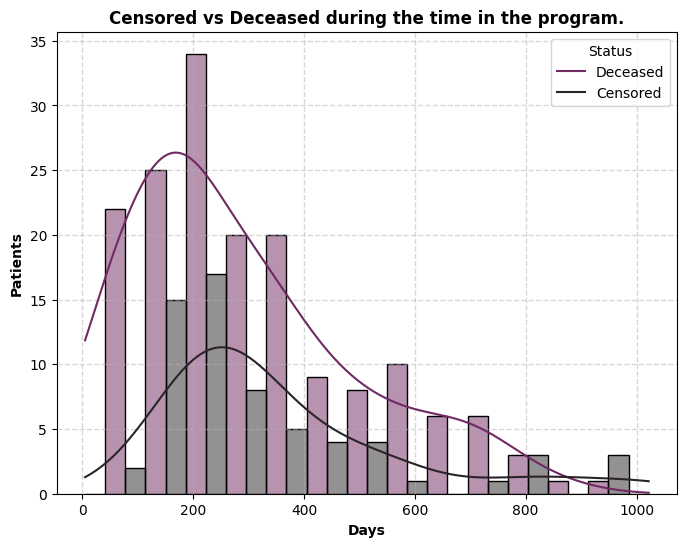

In [21]:
plt.figure(figsize = (8, 6))

sns.histplot(x = df_eda['time'], hue = df_eda['status'], kde = True, multiple = 'dodge', palette = 'dark:#702963')

plt.title("Censored vs Deceased during the time in the program.", fontweight = 'bold', fontsize = 12)
plt.xlabel('Days', fontweight = 'bold', fontsize = 10)
plt.ylabel('Patients', fontweight = 'bold')
plt.legend(title = 'Status', labels = ['Deceased', 'Censored'])
plt.grid(True, linestyle = '--', linewidth = 1, alpha = 0.5)

plt.show()

Time spent in the program:

- The first $400$ days spent is where more events occured, not even Deceased, but also Censored. Exhibing the first year during program is critical.

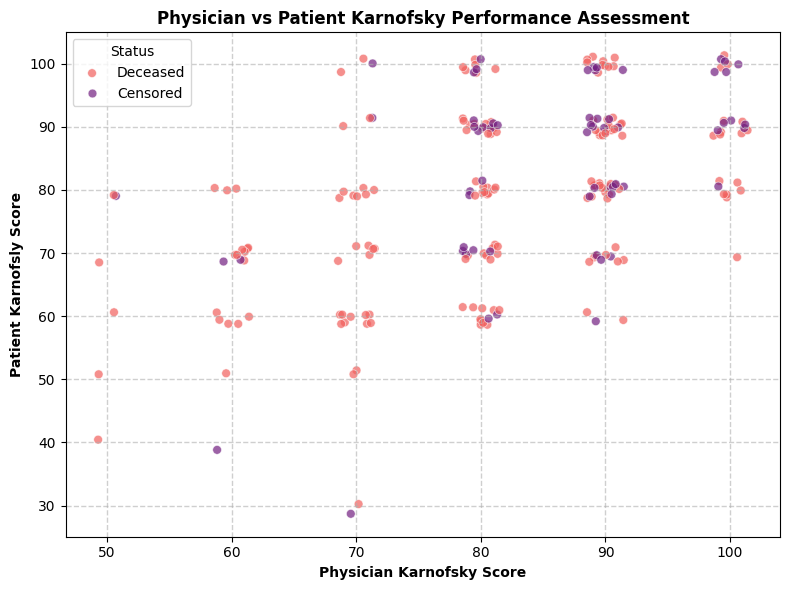

In [22]:
df_eda['ph_karno_jitter'] = df_eda['ph.karno'] + np.random.uniform(-1.5, 1.5, size = len(df_eda))
df_eda['pat_karno_jitter'] = df_eda['pat.karno'] + np.random.uniform(-1.5, 1.5, size = len(df_eda))

plt.figure(figsize = (8, 6))
sns.scatterplot(x = df_eda['ph_karno_jitter'], y = df_eda['pat_karno_jitter'], hue = df_eda['status'], palette = 'magma', alpha = 0.7, s = 40)

plt.xlabel('Physician Karnofsky Score', fontweight = 'bold', fontsize = 10)
plt.ylabel('Patient Karnofsly Score', fontweight = 'bold', fontsize = 10)
plt.title('Physician vs Patient Karnofsky Performance Assessment', fontweight = 'bold')
plt.grid(True, linestyle = '--', alpha = 0.6, linewidth = 1)
plt.legend(title = 'Status', labels = ['Deceased', 'Censored'])
plt.tight_layout()

plt.show()


We can see a slight correlation between the Patient score and the Physician score.

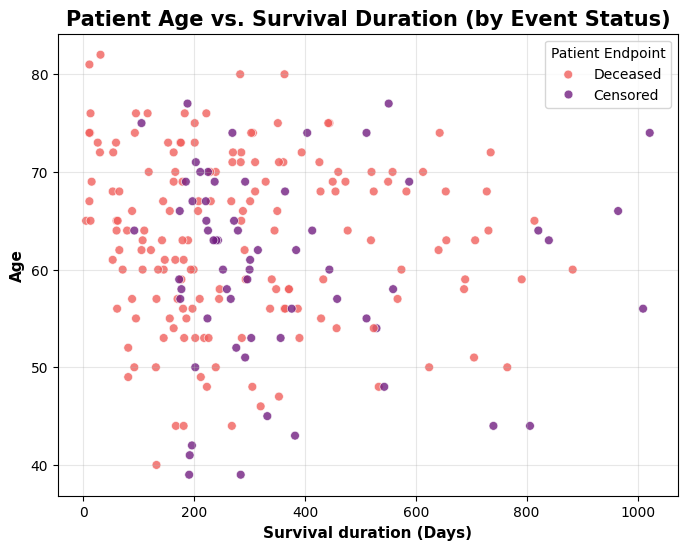

In [23]:
plt.figure(figsize = (8, 6))
sns.scatterplot(x = df_eda['time'], y = df_eda['age'], hue = df_eda['status'], palette = 'magma', alpha = 0.8, s = 40)
plt.title("Patient Age vs. Survival Duration (by Event Status)", fontsize = 15, fontweight = 'bold')
plt.ylabel('Age', fontsize = 11, fontweight = 'bold')
plt.xlabel('Survival duration (Days)', fontsize = 11, fontweight = 'bold')
plt.grid(True, linestyle = "-", alpha = 0.3)

plt.legend(title = "Patient Endpoint", labels = ['Deceased', 'Censored'])
plt.show()

Patient Age vs. Follow-up Duration

- Early Mortality Clustering: Event occurrences are heavily concentrated within the initial 400-day window, establishing the first year post-enrollment as the primary critical risk period.

- Weak Age Prognosis: Chronological age displays minimal linear correlation with survival duration, indicating that age alone is a weak standalone predictor compared to functional performance metrics.

- Methodological Boundary: While scatter plots illustrate raw observation patterns, unadjusted duration plots fail to account for right-censoring. Downstream survival stratification for high-impact predictors (sex, ph.ecog, and binned wt.loss) will rely strictly on non-parametric Kaplan-Meier estimators.

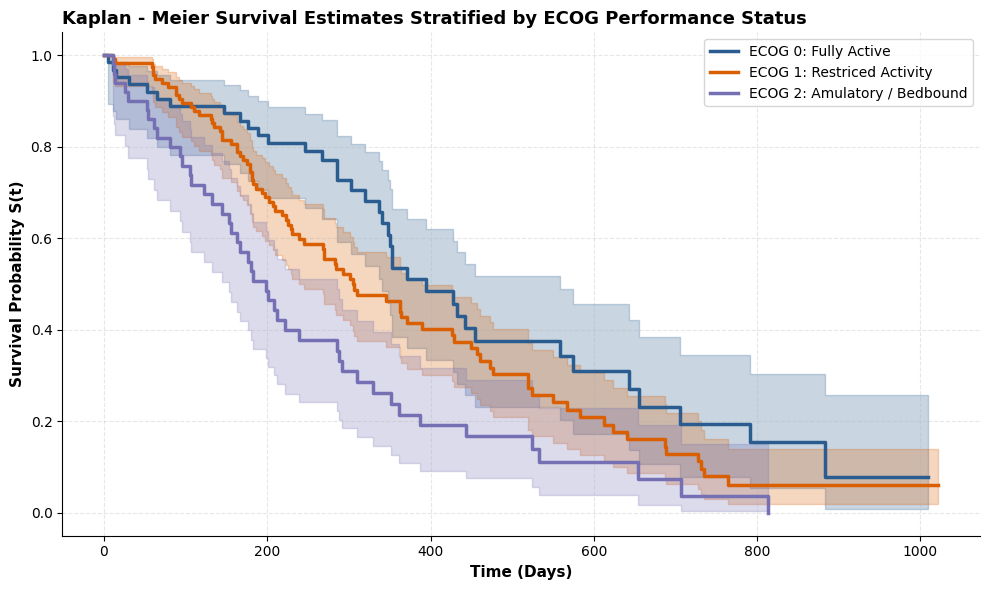

In [24]:
fig, ax = plt.subplots(figsize = (10, 6))

ecog_colors = {0: '#2b5c8f', 1: '#d95f02', 2: '#7570b3'}
ecog_labels = { 0: 'ECOG 0: Fully Active', 1: 'ECOG 1: Restriced Activity', 2: 'ECOG 2: Amulatory / Bedbound'}

for score in [0,1,2]:

  mask = (df_eda['ph.ecog'] == score)
  kmf.fit(durations = df_eda.loc[mask, 'time'], event_observed = df_eda.loc[mask, 'status'], label = ecog_labels[score])

  kmf.plot_survival_function(ax = ax, ci_show = True, color = ecog_colors[score], linewidth = 2.5)

plt.title('Kaplan - Meier Survival Estimates Stratified by ECOG Performance Status', fontsize = 13, fontweight = 'bold', loc = 'left')
plt.xlabel('Time (Days)', fontsize = 11, fontweight = 'bold')
plt.ylabel('Survival Probability S(t)', fontsize = 11, fontweight = 'bold')
plt.grid(True, linestyle = '--', alpha = 0.3)
sns.despine()

plt.tight_layout()
plt.show()


Kaplan-Meier Performance Status (ECOG) Stratification

- Functional Gradient: Patient survival shows a strong, dose-dependent relationship with ECOG performance status: baseline physical functionality heavily dictates survival duration.

- Median Survival Disparity: ECOG 0 patients achieve more than double the median survival duration of ECOG 2 patients (~500+ days vs. ~200 days).

- Late-Stage Flattening: Horizontal tail behavior beyond 800 days reflects heavy right-censoring and low event density rather than long-term recovery stabilization.

Modeling Implication: ph.ecog provides a stronger prognostic signal than chronological age and must be prioritized in multivariate feature selection.

In [33]:
ecogs = multivariate_logrank_test(event_durations = df_eda['time'], event_observed = df_eda['status'], groups = df_eda['ph.ecog'])

ecogs.print_summary()


### Statistical Validation: Multivariate Log-Rank Test for ECOG Status
- **Null Hypothesis ($H_0$):** Survival distributions are identical across all ECOG performance status groups.
- **Alternative Hypothesis ($H_1$):** At least one ECOG performance tier exhibits a statistically distinct survival distribution.
- **Test Result:** Multivariate Log-Rank $\chi^2 = 21.62$, $df = 3$, $p = 0.000078$ ($-\log_2(p) = 13.64$).
- **Statistical Decision:** Reject $H_0$ ($p \ll 0.05$).
- **Clinical Conclusion:** Baseline physical performance status (`ph.ecog`) is statistically validated as the single strongest univariate predictor of mortality risk in this cohort.

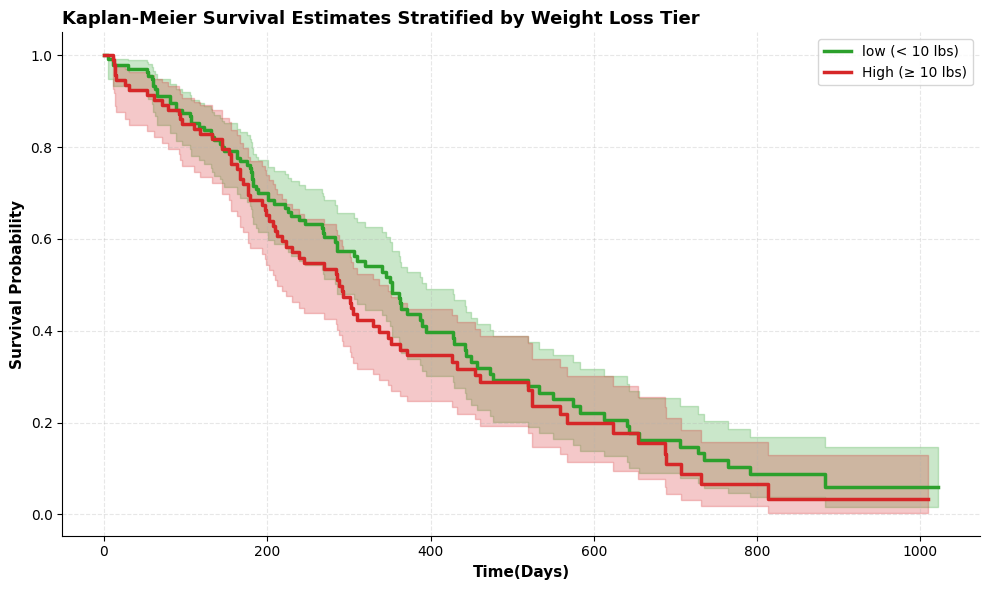

In [25]:
df_eda['wt_loss_group'] = np.where(df_eda['wt.loss'] < 10, 'low (< 10 lbs)', 'High (≥ 10 lbs)')

fig, ax = plt.subplots(figsize = (10, 6))

colors = {'low (< 10 lbs)': '#2ca02c', 'High (≥ 10 lbs)': '#d62728'}

for group_name in ['low (< 10 lbs)', 'High (≥ 10 lbs)']:
  mask = (df_eda['wt_loss_group'] == group_name)
  kmf.fit(durations = df_eda.loc[mask, 'time'], event_observed = df_eda.loc[mask, 'status'], label = group_name)

  kmf.plot_survival_function(ax = ax, ci_show = True, color = colors[group_name], linewidth = 2.5)

plt.title('Kaplan-Meier Survival Estimates Stratified by Weight Loss Tier', fontsize = 13, fontweight = 'bold', loc = 'left')
plt.xlabel('Time(Days)', fontsize = 11, fontweight = 'bold')
plt.ylabel('Survival Probability', fontsize = 11, fontweight = 'bold')
plt.grid(True, linestyle = '--', alpha = 0.3)
sns.despine()
plt.tight_layout()

plt.show()

Kaplan-Meier Weight Loss Tier Stratification:

- Directional Trend: Patients with pre-enrollment weight loss $\ge 10$ lbs exhibit systematically lower survival probability across the follow-up window.

- Confidence Band Overlap: Extensive overlap between $95\%$ confidence intervals indicates substantial variance, showing that a binary $10$ lbs cutoff is a weaker standalone predictor than sex or ph.ecog.

- Modeling Implication: Binary binning dilutes the prognostic value of weight loss. It should be evaluated continuously or tested for interaction effects with performance status in multivariate Cox modeling.

In [26]:
low_wt = (df_eda['wt_loss_group'] == 'low (< 10 lbs)')
high_wt = (df_eda['wt_loss_group'] == 'High (≥ 10 lbs)')

results_wt = logrank_test(durations_A= df_eda.loc[low_wt, 'time'], durations_B= df_eda.loc[high_wt, 'time'],
                          event_observed_A= df_eda.loc[low_wt, 'status'], event_observed_B= df_eda.loc[high_wt, 'status'])

results_wt.print_summary()

Statistical Validation: Log-Rank Test for Weight Loss Tier (<10 lbs vs. ≥10 lbs)
- **Null Hypothesis ($H_0$):** Survival distributions do not differ between low (<10 lbs) and high (≥10 lbs) pre-trial weight loss.
- **Test Result:** Log-Rank $\chi^2 = 1.30$, $p = 0.25$.
- **Statistical Decision:** Fail to reject $H_0$ ($p > 0.05$).
- **Clinical Takeaway:** An arbitrary binary cutoff at 10 lbs dilutes the predictive signal of weight loss. It should be evaluated as a continuous feature or tested inside a multivariate model alongside confounding factors like `ph.ecog`.

# Exploratory Data Analysis: Key Synthesis & Findings

Univariate Distribution:
 - Demographics: The cohort ($N=228$) is male-predominant, with patient ages spanning 39 to 82 years (median age: 62).

 - Event Density: High observed mortality event rate (72.4%), with remaining non-event patients classified as right-censored.

 Bivariate Survival Stratification:

 - Biological Sex: Female patients exhibited a significantly higher survival probability than males (Log-Rank $\chi^2 = 10.33, p = 0.0013$), validating sex as a foundational prognostic variable.

 - Performance Status: ph.ecog demonstrated a clear, dose-dependent survival gradient, far outperforming chronological age as a standalone predictor.

 - Weight Loss: Binned weight loss ($\ge 10$ lbs vs. $< 10$ lbs) showed a directional survival penalty, but lacked univariate statistical significance (Log-Rank $p = 0.25$).

 Data Quality & Preprocessing:

 - Sanity Checks: Verified zero duplicate records or redundant columns. Dropped institution ID (inst) as an uninformative administrative feature.

 - Imputation Strategy: Baseline median imputation was applied strictly for exploratory charting. Model development will utilize leak-free, production-grade pipelines.

 Next Steps: Multivariate Survival Modeling Phase

 1. Production Pipeline Engineering: Construct a modular Scikit-Learn ColumnTransformer featuring KNNImputer, one-hot encoding, and feature scaling inside cross-validation splits to eliminate data leakage.

 2. Multivariate Cox Proportional Hazards: Fit a Cox PH model (CoxPHFitter) to calculate Hazard Ratios (HR) and identify independent mortality risk factors while controlling for confounding variables.

 3. Model Evaluation: Measure ranking performance using the Concordance Index (C-Index).

In [37]:
df['ph.ecog'] = df['ph.ecog'].replace({3: 2})

df.to_csv('/content/drive/MyDrive/Colab Notebooks/df_NCCCG.csv', index = False)